DATA QUALITY & SEPARABILITY ANALYSIS

Analyzing classes: [7, 9, 10, 11, 15]
  Recon attacks: [7, 9, 10]
  ICMP attacks: [11, 15]

1. CLASS DISTRIBUTION
Class 7: 800 samples
Class 9: 800 samples
Class 10: 800 samples
Class 11: 2400 samples
Class 15: 1200 samples

2. FEATURE STATISTICS BY CLASS

--- RECON CLASSES (7, 9, 10) FEATURE DIFFERENCES ---

Top 15 most discriminative features:
            feature        cv  mean_class_7  mean_class_9  mean_class_10
27             IGMP  1.414214      0.000000      0.000000       0.000125
10  cwr_flag_number  1.414214      0.000625      0.000000       0.000000
24             DHCP  1.414214      0.000375      0.000000       0.000000
9   ece_flag_number  1.414214      0.000750      0.000000       0.000000
38         Variance  1.142406   2074.487583   8531.546514   70931.264361
23              UDP  1.140990      0.006625      0.045000       0.340125
34              Std  1.001320     11.941586     24.113958     147.721917
17              DNS  0.969765 

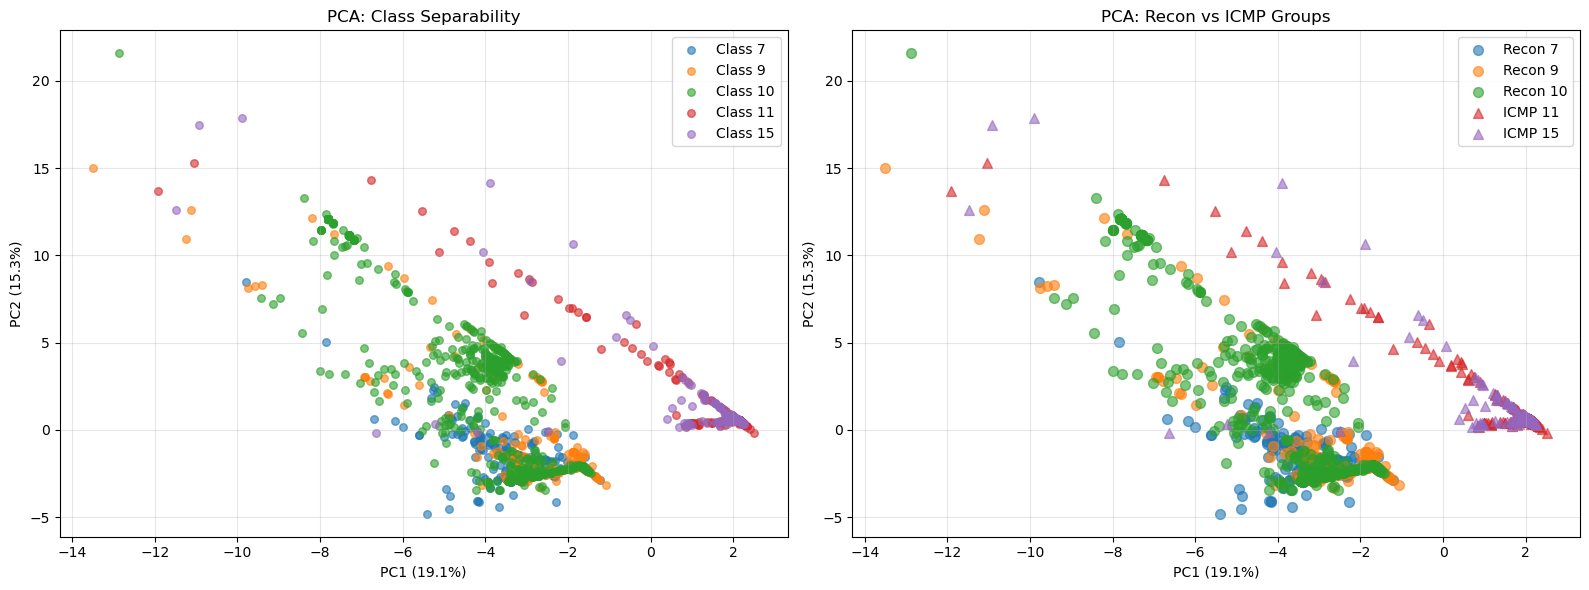

In [4]:
"""
Label feature overlap analysis

Author: Tan Yi Feng
Student ID: 23WMR14766
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import joblib
import pickle
import pandas as pd


SCRIPT_DIR = Path.cwd()


DATA_PATH = SCRIPT_DIR / 'data'/ 'FYP_Processed_Data'/'balanced_train_data.csv'
CONFIG_PATH = SCRIPT_DIR / 'config' / 'config.yaml'
MODELS_DIR = SCRIPT_DIR / 'data' / 'models'
SRC_PATH = SCRIPT_DIR / 'src'

sys.path.append(str(SRC_PATH))

print("="*70)
print("DATA QUALITY & SEPARABILITY ANALYSIS")
print("="*70)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
target_col = 'label' if 'label' in df.columns else 'Label'

# Focus on problematic classes
recon_classes = [7, 9, 10]
icmp_classes = [11, 15]
problematic_classes = recon_classes + icmp_classes

print(f"\nAnalyzing classes: {problematic_classes}")
print(f"  Recon attacks: {recon_classes}")
print(f"  ICMP attacks: {icmp_classes}")



print("\n" + "="*70)
print("1. CLASS DISTRIBUTION")
print("="*70)

for cls in problematic_classes:
    count = len(df[df[target_col] == cls])
    print(f"Class {cls}: {count} samples")



print("\n" + "="*70)
print("2. FEATURE STATISTICS BY CLASS")
print("="*70)

feature_cols = df.drop(columns=[target_col]).select_dtypes(include=['number']).columns

def analyze_class_differences(df, classes, feature_cols):
    """Calculate statistical differences between classes"""
    
    results = []
    
    for feature in feature_cols:
       
        class_values = {cls: df[df[target_col] == cls][feature].values for cls in classes}
        
        
        means = {}
        stds = {}
        for cls, vals in class_values.items():
            # Clean data
            vals_clean = vals[np.isfinite(vals)]
            if len(vals_clean) > 0:
                means[cls] = np.mean(vals_clean)
                stds[cls] = np.std(vals_clean)
            else:
                means[cls] = 0
                stds[cls] = 0
        
        
        mean_of_means = np.mean(list(means.values()))
        std_of_means = np.std(list(means.values()))
        cv = (std_of_means / abs(mean_of_means)) if mean_of_means != 0 else 0
        
        
        if not np.isfinite(cv):
            cv = 0
        
        results.append({
            'feature': feature,
            'cv': cv,
            **{f'mean_class_{cls}': means[cls] for cls in classes},
            **{f'std_class_{cls}': stds[cls] for cls in classes}
        })
    
    return pd.DataFrame(results).sort_values('cv', ascending=False)


print("\n--- RECON CLASSES (7, 9, 10) FEATURE DIFFERENCES ---")
recon_diff = analyze_class_differences(df, recon_classes, feature_cols)
print("\nTop 15 most discriminative features:")
print(recon_diff[['feature', 'cv', 'mean_class_7', 'mean_class_9', 'mean_class_10']].head(15))

print("\nBottom 10 least discriminative features (PROBLEM!):")
print(recon_diff[['feature', 'cv', 'mean_class_7', 'mean_class_9', 'mean_class_10']].tail(10))


print("\n--- ICMP CLASSES (11, 15) FEATURE DIFFERENCES ---")
icmp_diff = analyze_class_differences(df, icmp_classes, feature_cols)
print("\nTop 10 most discriminative features:")
print(icmp_diff[['feature', 'cv', 'mean_class_11', 'mean_class_15']].head(10))

print("\nBottom 10 least discriminative features (PROBLEM!):")
print(icmp_diff[['feature', 'cv', 'mean_class_11', 'mean_class_15']].tail(10))

print("\n" + "="*70)
print("3. FEATURE VALUE OVERLAP ANALYSIS")
print("="*70)

def calculate_overlap(df, class1, class2, feature):
    """Calculate overlap coefficient between two classes for a feature"""
    vals1 = df[df[target_col] == class1][feature].values
    vals2 = df[df[target_col] == class2][feature].values
    
    
    vals1 = vals1[np.isfinite(vals1)]
    vals2 = vals2[np.isfinite(vals2)]
    
    
    if len(vals1) == 0 or len(vals2) == 0:
        return 0
    
    min_val = min(vals1.min(), vals2.min())
    max_val = max(vals1.max(), vals2.max())
    
    if min_val == max_val or not np.isfinite(min_val) or not np.isfinite(max_val):
        return 1.0
    
    bins = np.linspace(min_val, max_val, 50)
    hist1, _ = np.histogram(vals1, bins=bins, density=True)
    hist2, _ = np.histogram(vals2, bins=bins, density=True)
    
    overlap = np.minimum(hist1, hist2).sum() / max(hist1.sum(), hist2.sum())
    
    
    if not np.isfinite(overlap):
        return 0.5
    
    return overlap

print("\n--- RECON CLASS OVERLAP ---")
overlap_results = []
for i, class1 in enumerate(recon_classes):
    for class2 in recon_classes[i+1:]:
        overlaps = []
        for feature in feature_cols[:20]:  # Check top 20 features
            overlap = calculate_overlap(df, class1, class2, feature)
            overlaps.append(overlap)
        avg_overlap = np.mean(overlaps)
        print(f"Class {class1} vs {class2}: {avg_overlap:.2%} average overlap")
        overlap_results.append((class1, class2, avg_overlap))

print("\n--- ICMP CLASS OVERLAP ---")
for class1 in icmp_classes:
    for class2 in icmp_classes:
        if class1 < class2:
            overlaps = []
            for feature in feature_cols[:20]:
                overlap = calculate_overlap(df, class1, class2, feature)
                overlaps.append(overlap)
            avg_overlap = np.mean(overlaps)
            print(f"Class {class1} vs {class2}: {avg_overlap:.2%} average overlap")


print("\n" + "="*70)
print("4. IDENTIFYING UNIQUE SIGNATURES")
print("="*70)


print("\n--- RECON ATTACK FLAG PATTERNS ---")
flag_features = ['syn_flag_number', 'ack_flag_number', 'rst_flag_number', 
                 'fin_flag_number', 'psh_flag_number']

for cls in recon_classes:
    print(f"\nClass {cls} flag statistics:")
    class_data = df[df[target_col] == cls]
    for flag in flag_features:
        mean_val = class_data[flag].mean()
        std_val = class_data[flag].std()
        nonzero_pct = (class_data[flag] > 0).mean() * 100
        print(f"  {flag}: mean={mean_val:.3f}, std={std_val:.3f}, nonzero={nonzero_pct:.1f}%")


print("\n--- ICMP ATTACK RATE & VOLUME PATTERNS ---")
rate_features = ['Rate', 'Number', 'IAT', 'ICMP', 'Tot size']

for cls in icmp_classes:
    print(f"\nClass {cls} rate/volume statistics:")
    class_data = df[df[target_col] == cls]
    for feature in rate_features:
        mean_val = class_data[feature].mean()
        median_val = class_data[feature].median()
        std_val = class_data[feature].std()
        print(f"  {feature}: mean={mean_val:.2f}, median={median_val:.2f}, std={std_val:.2f}")



print("\n" + "="*70)
print("5. DATA QUALITY CHECK")
print("="*70)


print("\n--- CHECKING FOR DUPLICATES ---")
for cls in problematic_classes:
    class_data = df[df[target_col] == cls].drop(columns=[target_col])
    duplicates = class_data.duplicated().sum()
    total = len(class_data)
    print(f"Class {cls}: {duplicates} duplicates out of {total} ({duplicates/total*100:.1f}%)")


print("\n--- CHECKING FOR CONSTANT FEATURES WITHIN CLASSES ---")
for cls in problematic_classes:
    class_data = df[df[target_col] == cls][feature_cols]
    constant_features = []
    for col in feature_cols:
        if class_data[col].std() == 0:
            constant_features.append(col)
    if constant_features:
        print(f"Class {cls}: {len(constant_features)} constant features - {constant_features[:5]}")
    else:
        print(f"Class {cls}: No constant features")


print("\n" + "="*70)
print("6. VISUALIZING CLASS SEPARABILITY")
print("="*70)


vis_data = df[df[target_col].isin(problematic_classes)].copy()
X_vis = vis_data.drop(columns=[target_col]).select_dtypes(include=['number'])
y_vis = vis_data[target_col]


X_vis.replace([np.inf, -np.inf], np.nan, inplace=True)
X_vis.fillna(X_vis.median(), inplace=True)


if np.any(np.isinf(X_vis.values)) or np.any(np.isnan(X_vis.values)):
    print("⚠️  Warning: Cleaning remaining invalid values...")
    X_vis = X_vis.fillna(0)
    X_vis = X_vis.replace([np.inf, -np.inf], 0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)


print("\nPerforming PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
print(f"PCA explained variance: {explained_var[0]:.2%} + {explained_var[1]:.2%} = {sum(explained_var):.2%}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


for cls in problematic_classes:
    mask = y_vis == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   label=f'Class {cls}', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({explained_var[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({explained_var[1]:.1%})')
axes[0].set_title('PCA: Class Separability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


recon_mask = y_vis.isin(recon_classes)
icmp_mask = y_vis.isin(icmp_classes)

for cls in recon_classes:
    mask = y_vis == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   label=f'Recon {cls}', alpha=0.6, s=50, marker='o')

for cls in icmp_classes:
    mask = y_vis == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   label=f'ICMP {cls}', alpha=0.6, s=50, marker='^')

axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1%})')
axes[1].set_title('PCA: Recon vs ICMP Groups')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('class_separability_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved to 'class_separability_analysis.png'")



print("\n" + "="*70)
print("7. DIAGNOSIS & RECOMMENDATIONS")
print("="*70)

print("\n🔍 FINDINGS:")


avg_recon_overlap = np.mean([x[2] for x in overlap_results])
print(f"\n1. Recon classes have {avg_recon_overlap:.1%} average feature overlap")
if avg_recon_overlap > 0.7:
    print("   ⚠️  HIGH OVERLAP - Classes are very similar in feature space")
    print("   → These attacks may be inherently difficult to distinguish")
elif avg_recon_overlap > 0.5:
    print("   ⚠️  MODERATE OVERLAP - Better features needed")
else:
    print("   ✓ LOW OVERLAP - Model should be able to separate these")

print(f"\n2. Feature discriminative power:")
high_cv_features = recon_diff[recon_diff['cv'] > 0.5]
print(f"   - {len(high_cv_features)} features have good discriminative power (CV > 0.5)")
low_cv_features = recon_diff[recon_diff['cv'] < 0.1]
print(f"   - {len(low_cv_features)} features have poor discriminative power (CV < 0.1)")

print("\n💡 RECOMMENDATIONS:")

print("\n1. For Recon Attacks (7, 9, 10):")
print("   → If overlap > 70%: Consider merging into single 'Recon' class")
print("   → Try ensemble of different algorithm types (RF + XGBoost + SVM)")
print("   → Add temporal features if timestamp data available")
print("   → Check if original PCAP files have additional metadata")

print("\n2. For ICMP Attacks (11, 15):")
print("   → Focus on rate-based features (packets per second)")
print("   → Add source IP diversity metrics if available")
print("   → Consider time-windowed aggregations")

print("\n3. Data Collection:")
print("   → Verify if classes 7, 9, 10 are truly different attack types")
print("   → Check if data was collected from same source/time period")
print("   → Consider collecting more diverse samples")

print("\n4. Alternative Approaches:")
print("   → Use hierarchical classification (as in previous script)")
print("   → Apply cost-sensitive learning (penalize Recon misclassification more)")
print("   → Try deep learning (1D CNN or LSTM for sequential patterns)")

print("\n" + "="*70)

DATA QUALITY & SEPARABILITY ANALYSIS — ALL MERGE GROUPS

GROUP: MQTT_Connect  →  classes [2, 4]

[1] CLASS DISTRIBUTION
  Class 2: 800 samples
  Class 4: 800 samples

[2] FEATURE STATISTICS

  Top 10 most discriminative features:
        feature       cv  mean_class_2  mean_class_4
            DNS 1.000000      0.000000      0.000025
           DHCP 1.000000      0.000000      0.000013
            IAT 0.835075      0.000030      0.000335
            ARP 0.750000      0.000013      0.000088
            UDP 0.700000      0.000037      0.000212
           Rate 0.664355  48111.233111   9702.421218
       Variance 0.475796     40.162937    113.071180
fin_flag_number 0.457156      0.199556      0.074342
      fin_count 0.456746     19.933750      7.433750
          HTTPS 0.355932      0.000238      0.000500

  Bottom 5 least discriminative features:
        feature  cv  mean_class_2  mean_class_4
         Telnet 0.0           0.0           0.0
           HTTP 0.0           0.0           0.0


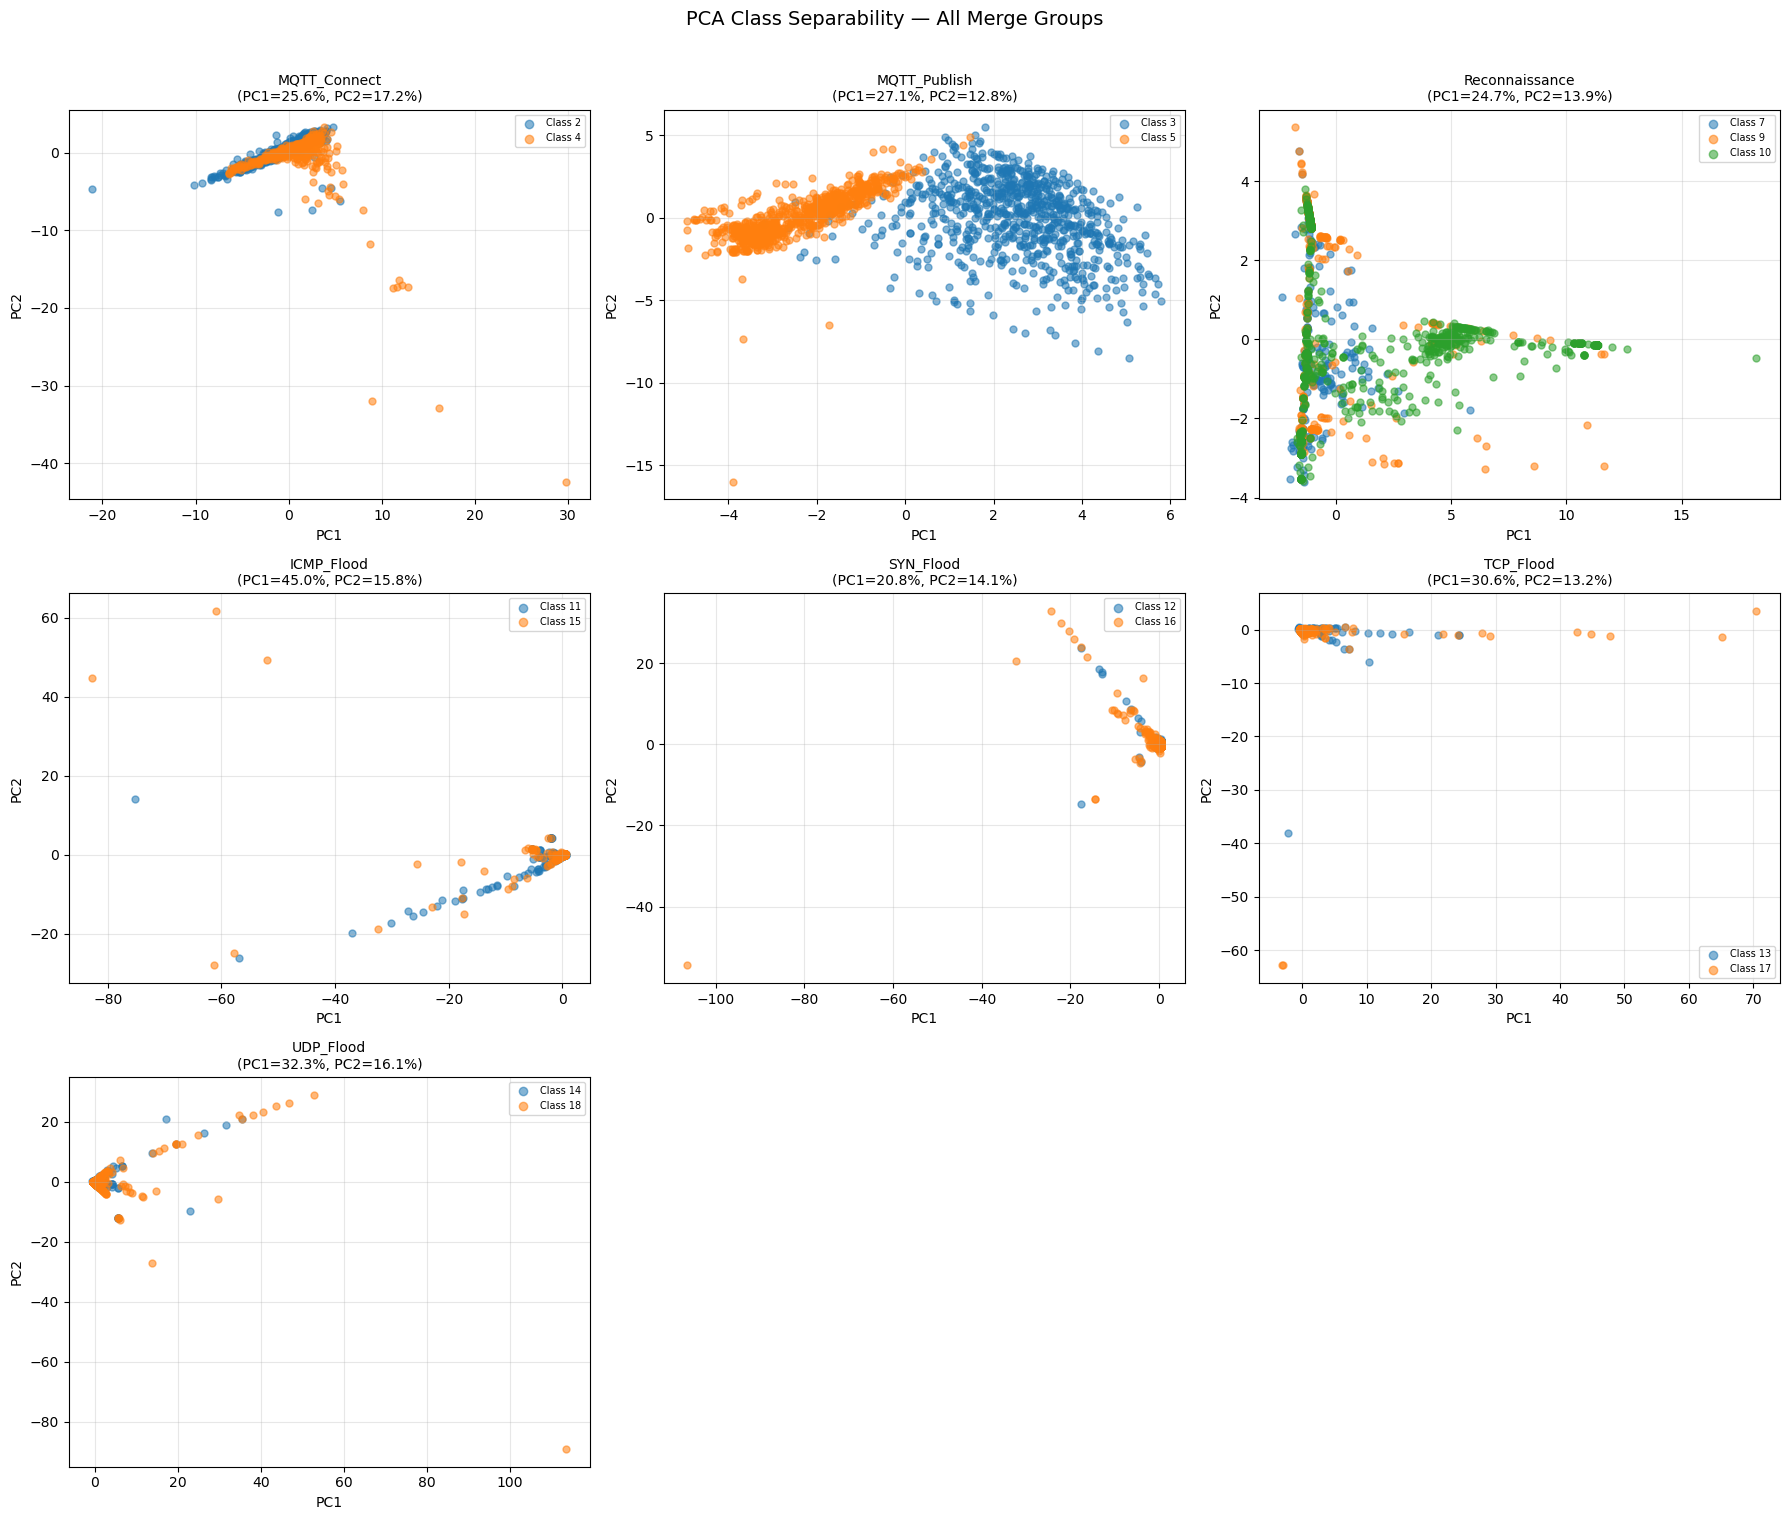

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')



DATA_PATH = SCRIPT_DIR / 'data' / 'FYP_Processed_Data'/'balanced_train_data.csv'



merge_groups = {
    "MQTT_Connect":   [2, 4],
    "MQTT_Publish":   [3, 5],
    "Reconnaissance": [7, 9, 10],
    "ICMP_Flood":     [11, 15],
    "SYN_Flood":      [12, 16],
    "TCP_Flood":      [13, 17],
    "UDP_Flood":      [14, 18],
}

print("="*70)
print("DATA QUALITY & SEPARABILITY ANALYSIS — ALL MERGE GROUPS")
print("="*70)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
target_col = 'label' if 'label' in df.columns else 'Label'

feature_cols = df.drop(columns=[target_col]).select_dtypes(include=['number']).columns


def analyze_class_differences(df, target_col, classes, feature_cols):
    """Calculate statistical differences (CV) between classes for every feature."""
    results = []
    for feature in feature_cols:
        class_values = {
            cls: df[df[target_col] == cls][feature].values
            for cls in classes
        }
        means = {}
        stds = {}
        for cls, vals in class_values.items():
            vals_clean = vals[np.isfinite(vals)]
            means[cls] = np.mean(vals_clean) if len(vals_clean) > 0 else 0
            stds[cls]  = np.std(vals_clean)  if len(vals_clean) > 0 else 0

        mean_of_means = np.mean(list(means.values()))
        std_of_means  = np.std(list(means.values()))
        cv = (std_of_means / abs(mean_of_means)) if mean_of_means != 0 else 0
        cv = cv if np.isfinite(cv) else 0

        results.append({
            'feature': feature,
            'cv': cv,
            **{f'mean_class_{cls}': means[cls] for cls in classes},
            **{f'std_class_{cls}':  stds[cls]  for cls in classes},
        })

    return pd.DataFrame(results).sort_values('cv', ascending=False)


def calculate_overlap(df, target_col, class1, class2, feature):
    """Histogram-intersection overlap coefficient between two classes."""
    vals1 = df[df[target_col] == class1][feature].values
    vals2 = df[df[target_col] == class2][feature].values
    vals1 = vals1[np.isfinite(vals1)]
    vals2 = vals2[np.isfinite(vals2)]

    if len(vals1) == 0 or len(vals2) == 0:
        return 0

    min_val = min(vals1.min(), vals2.min())
    max_val = max(vals1.max(), vals2.max())

    if min_val == max_val or not np.isfinite(min_val) or not np.isfinite(max_val):
        return 1.0

    bins = np.linspace(min_val, max_val, 50)
    hist1, _ = np.histogram(vals1, bins=bins, density=True)
    hist2, _ = np.histogram(vals2, bins=bins, density=True)

    denom = max(hist1.sum(), hist2.sum())
    if denom == 0:
        return 0.5
    overlap = np.minimum(hist1, hist2).sum() / denom
    return overlap if np.isfinite(overlap) else 0.5


def pairwise_overlap(df, target_col, classes, feature_cols, max_features=20):
    """Return list of (class1, class2, avg_overlap) tuples."""
    results = []
    for i, c1 in enumerate(classes):
        for c2 in classes[i+1:]:
            overlaps = [
                calculate_overlap(df, target_col, c1, c2, f)
                for f in feature_cols[:max_features]
            ]
            results.append((c1, c2, float(np.mean(overlaps))))
    return results




n_groups = len(merge_groups)
ncols = 3
nrows = int(np.ceil(n_groups / ncols))

fig_pca, axes_pca = plt.subplots(nrows, ncols,
                                  figsize=(6 * ncols, 5 * nrows))
axes_pca = axes_pca.flatten()

group_overlap_summary = {}   



for group_idx, (group_name, classes) in enumerate(merge_groups.items()):

    print("\n" + "="*70)
    print(f"GROUP: {group_name}  →  classes {classes}")
    print("="*70)

   
    print("\n[1] CLASS DISTRIBUTION")
    for cls in classes:
        count = len(df[df[target_col] == cls])
        print(f"  Class {cls}: {count} samples")

   
    print("\n[2] FEATURE STATISTICS")
    diff_df = analyze_class_differences(df, target_col, classes, feature_cols)

    mean_cols = [f'mean_class_{c}' for c in classes]
    print(f"\n  Top 10 most discriminative features:")
    print(diff_df[['feature', 'cv'] + mean_cols].head(10).to_string(index=False))

    print(f"\n  Bottom 5 least discriminative features:")
    print(diff_df[['feature', 'cv'] + mean_cols].tail(5).to_string(index=False))

    high_cv = int((diff_df['cv'] > 0.5).sum())
    low_cv  = int((diff_df['cv'] < 0.1).sum())
    print(f"\n  Features with CV > 0.5 (good discriminative power): {high_cv}")
    print(f"  Features with CV < 0.1 (poor discriminative power):  {low_cv}")

    
    print("\n[3] PAIRWISE FEATURE OVERLAP (top-20 features)")
    overlaps = pairwise_overlap(df, target_col, classes, feature_cols)
    for c1, c2, ov in overlaps:
        print(f"  Class {c1} vs {c2}: {ov:.2%} average overlap")

    avg_overlap = float(np.mean([o for *_, o in overlaps])) if overlaps else 0.0
    group_overlap_summary[group_name] = avg_overlap

   
    print("\n[4] DATA QUALITY CHECK")
    for cls in classes:
        cdata = df[df[target_col] == cls].drop(columns=[target_col])
        dups  = cdata.duplicated().sum()
        total = len(cdata)
        print(f"  Class {cls}: {dups}/{total} duplicates ({dups/total*100:.1f}%)")

    for cls in classes:
        cdata = df[df[target_col] == cls][feature_cols]
        const = [c for c in feature_cols if cdata[c].std() == 0]
        if const:
            print(f"  Class {cls}: {len(const)} constant features — {const[:5]}")
        else:
            print(f"  Class {cls}: no constant features")

    
    vis_data = df[df[target_col].isin(classes)].copy()
    X_vis = vis_data.drop(columns=[target_col]).select_dtypes(include=['number'])
    y_vis = vis_data[target_col]

    X_vis.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_vis.fillna(X_vis.median(), inplace=True)
    X_vis.fillna(0, inplace=True)

    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X_vis)
    pca     = PCA(n_components=2)
    X_pca   = pca.fit_transform(X_sc)
    ev      = pca.explained_variance_ratio_

    ax = axes_pca[group_idx]
    for cls in classes:
        mask = (y_vis == cls).values
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'Class {cls}', alpha=0.55, s=25)

    ax.set_title(f'{group_name}\n(PC1={ev[0]:.1%}, PC2={ev[1]:.1%})', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=1.2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for idx in range(n_groups, len(axes_pca)):
    axes_pca[idx].set_visible(False)

plt.suptitle('PCA Class Separability — All Merge Groups', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('class_separability_all_groups.png', dpi=150, bbox_inches='tight')
print("\n✓ PCA grid saved to 'class_separability_all_groups.png'")



print("\n" + "="*70)
print("FINAL SUMMARY — AVERAGE PAIRWISE OVERLAP PER GROUP")
print("="*70)

for gname, ov in group_overlap_summary.items():
    flag = "⚠️  HIGH"   if ov > 0.70 else \
           "⚡ MODERATE" if ov > 0.50 else \
           "✓  LOW"
    print(f"  {gname:<18} {ov:.2%}  {flag}")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

for gname, ov in group_overlap_summary.items():
    classes = merge_groups[gname]
    print(f"\n{gname} (classes {classes})  —  overlap {ov:.2%}")
    if ov > 0.70:
        print("  → Very high overlap: merging these classes is strongly justified.")
        print("  → Model will likely struggle to separate them even after tuning.")
        print("  → Focus on gathering more discriminative features (e.g. timing,")
        print("     payload size, port patterns) before keeping them separate.")
    elif ov > 0.50:
        print("  → Moderate overlap: consider feature engineering or ensemble")
        print("     methods (RF + XGBoost + SVM) to improve separation.")
        print("  → Hierarchical classification may help (group first, then subtype).")
    else:
        print("  → Low overlap: a well-tuned model should distinguish these classes.")
        print("  → Ensure sufficient training samples per sub-class.")

print("\n  General tips:")
print("  • Cost-sensitive learning — penalise misclassification within a merge group")
print("    more heavily than across groups.")
print("  • For MQTT/IoT groups: protocol-level fields (QoS, retain flag) may help.")
print("  • For flood groups: rate-based features (pkts/sec, IAT mean/std) are key.")
print("  • Consider t-SNE on the most confusing group for a finer visual diagnosis.")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)